<a href="https://colab.research.google.com/github/eduzegarra/grade_01/blob/main/Ollas_prueba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [93]:
!python generate_lima_datasets.py

Generating synthetic INEI Census Blocks...
Generating formal Comedores Populares points...
Generating Ollas Comunes points and modeling survival...
Exported: inei_manzanas_sample.geojson (225 features)
Exported: comedores_populares_sample.geojson (85 features)
Exported: ollas_comunes_sample.geojson (120 features)

All datasets generated successfully and ready for Google Colab testing.


In [94]:
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
# 2. Ingest the generated GeoJSON files
gdf_censo = gpd.read_file("inei_manzanas_sample.geojson")
gdf_comedores = gpd.read_file("comedores_populares_sample.geojson")
gdf_ollas = gpd.read_file("ollas_comunes_sample.geojson")

In [95]:
gdf_ollas.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID_OLLA                 120 non-null    object        
 1   NOMBRE                  120 non-null    object        
 2   BENEFICIARIOS           120 non-null    int32         
 3   TIPO_COMBUSTIBLE        120 non-null    object        
 4   FECHA_REGISTRO          120 non-null    datetime64[ms]
 5   dist_nearest_comedor_m  120 non-null    float64       
 6   ESTADO                  120 non-null    object        
 7   geometry                120 non-null    geometry      
dtypes: datetime64[ms](1), float64(1), geometry(1), int32(1), object(4)
memory usage: 7.2+ KB


In [96]:
gdf_comedores.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   ID_COMEDOR     85 non-null     object  
 1   NOMBRE         85 non-null     object  
 2   BENEFICIARIOS  85 non-null     int32   
 3   ESTADO         85 non-null     object  
 4   geometry       85 non-null     geometry
dtypes: geometry(1), int32(1), object(3)
memory usage: 3.1+ KB


In [97]:
gdf_censo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   ID_MANZANA      225 non-null    object  
 1   POB_TOTAL       225 non-null    int32   
 2   NBI_AGUA_PCT    225 non-null    float64 
 3   NBI_HACINA_PCT  225 non-null    float64 
 4   ESTRATO_SE      225 non-null    object  
 5   grad_score      225 non-null    float64 
 6   geometry        225 non-null    geometry
dtypes: float64(3), geometry(1), int32(1), object(2)
memory usage: 11.6+ KB


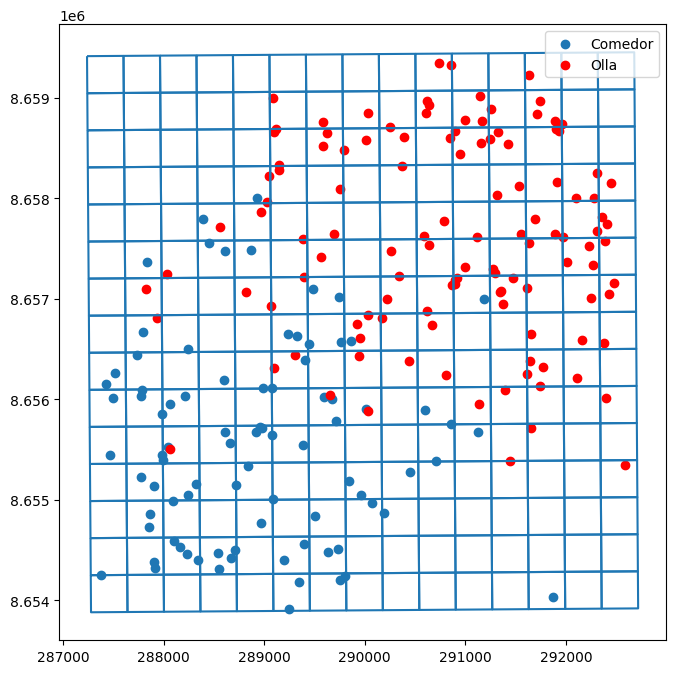

In [98]:
axis=gdf_censo.boundary.plot(figsize=(15,8))
gdf_comedores.plot(ax=axis, label='Comedor')
gdf_ollas.plot(ax=axis, color='red', label='Olla')
axis.legend()
plt.show()

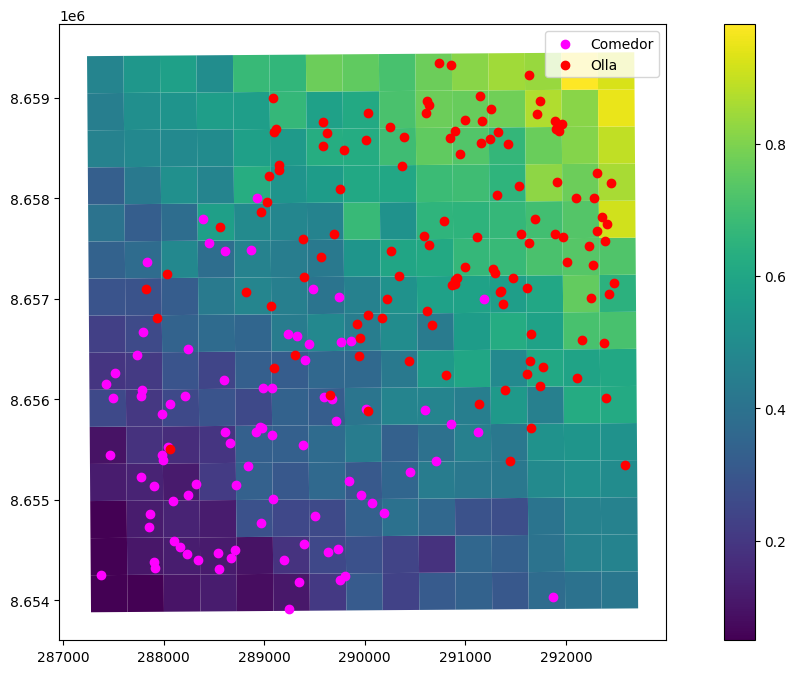

In [99]:
axis=gdf_censo.plot(column='grad_score',figsize=(15,8), legend=True)
gdf_comedores.plot(ax=axis, label='Comedor', color='magenta')
gdf_ollas.plot(ax=axis, color='red', label='Olla')
axis.legend()
plt.show()

In [100]:
joined = gpd.sjoin(gdf_ollas, gdf_censo, how="left", predicate="intersects")

In [101]:
joined.columns

Index(['ID_OLLA', 'NOMBRE', 'BENEFICIARIOS', 'TIPO_COMBUSTIBLE',
       'FECHA_REGISTRO', 'dist_nearest_comedor_m', 'ESTADO', 'geometry',
       'index_right', 'ID_MANZANA', 'POB_TOTAL', 'NBI_AGUA_PCT',
       'NBI_HACINA_PCT', 'ESTRATO_SE', 'grad_score'],
      dtype='object')

In [102]:
n_ollas=joined.rename(columns={'ID_OLLA':'num_ollas'}).groupby('ID_MANZANA').agg({'num_ollas':'count'})

In [103]:
gdf_censo=gdf_censo.merge(n_ollas, on='ID_MANZANA', how='left')

In [104]:
len(gdf_censo)

225

In [105]:
gdf_censo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   ID_MANZANA      225 non-null    object  
 1   POB_TOTAL       225 non-null    int32   
 2   NBI_AGUA_PCT    225 non-null    float64 
 3   NBI_HACINA_PCT  225 non-null    float64 
 4   ESTRATO_SE      225 non-null    object  
 5   grad_score      225 non-null    float64 
 6   geometry        225 non-null    geometry
 7   num_ollas       79 non-null     float64 
dtypes: float64(4), geometry(1), int32(1), object(2)
memory usage: 13.3+ KB


In [106]:
gdf_censo.loc[gdf_censo.num_ollas.isna(),'num_ollas']=0

In [107]:
gdf_censo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   ID_MANZANA      225 non-null    object  
 1   POB_TOTAL       225 non-null    int32   
 2   NBI_AGUA_PCT    225 non-null    float64 
 3   NBI_HACINA_PCT  225 non-null    float64 
 4   ESTRATO_SE      225 non-null    object  
 5   grad_score      225 non-null    float64 
 6   geometry        225 non-null    geometry
 7   num_ollas       225 non-null    float64 
dtypes: float64(4), geometry(1), int32(1), object(2)
memory usage: 13.3+ KB


In [108]:
# Finds the closest feature in 'comedores' for each row in 'grid_base'
temp=gpd.sjoin_nearest(gdf_censo,gdf_comedores,how="left", distance_col="d_comedor")

In [109]:
censo=temp.drop_duplicates(subset='ID_MANZANA')

<Axes: ylabel='Density'>

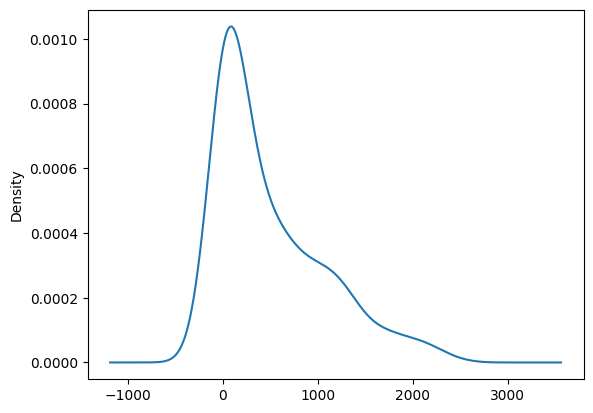

In [110]:
censo.d_comedor.plot(kind='kde')

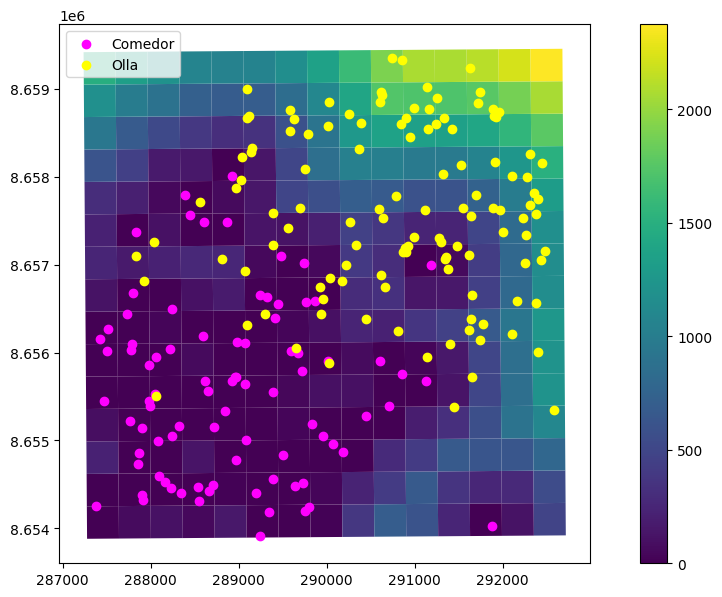

In [111]:
axis=censo.plot(column='d_comedor',figsize=(13,7), legend=True)
gdf_comedores.plot(ax=axis, label='Comedor', color='magenta')
gdf_ollas.plot(ax=axis, color='yellow', label='Olla')
axis.legend()
plt.show()

In [112]:
censo['has_olla']=(censo.num_ollas>0).astype('int')

/usr/local/lib/python3.13/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [114]:
censo.groupby('has_olla').agg({'d_comedor':'mean',
 'POB_TOTAL':'mean',
 'NBI_AGUA_PCT':'mean',
 'NBI_HACINA_PCT':'mean',
 'grad_score':'mean',
 'num_ollas':'mean'})

,d_comedor,POB_TOTAL,NBI_AGUA_PCT,NBI_HACINA_PCT,grad_score,num_ollas
has_olla,,,,,,
0,394.607353,284.534247,34.637877,16.802192,0.392270,0.000000
1,684.520485,276.392405,52.749873,25.436329,0.599597,1.518987


In [115]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import numpy as np

In [116]:
censo['log_pob']=np.log(np.maximum(censo["POB_TOTAL"], 1))

/usr/local/lib/python3.13/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [117]:
censo['log_dist']=np.log(np.maximum(censo["d_comedor"], 1))

/usr/local/lib/python3.13/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [118]:
censo.columns

Index(['ID_MANZANA', 'POB_TOTAL', 'NBI_AGUA_PCT', 'NBI_HACINA_PCT',
       'ESTRATO_SE', 'grad_score', 'geometry', 'num_ollas', 'index_right',
       'ID_COMEDOR', 'NOMBRE', 'BENEFICIARIOS', 'ESTADO', 'd_comedor',
       'has_olla', 'log_pob', 'log_dist'],
      dtype='object')

In [125]:
formula = (
    "has_olla ~ log_dist + "
    #"NBI_AGUA_PCT + "
    # "NBI_HACINA_PCT + "
    "log_pob"
)

In [126]:
probit_model = smf.probit(formula=formula, data=censo).fit(cov_type="HC1")
print(probit_model.summary())

Optimization terminated successfully.
         Current function value: 0.597344
         Iterations 5
                          Probit Regression Results                           
Dep. Variable:               has_olla   No. Observations:                  225
Model:                         Probit   Df Residuals:                      222
Method:                           MLE   Df Model:                            2
Date:                Sat, 12 Sep 2026   Pseudo R-squ.:                 0.07836
Time:                        10:46:25   Log-Likelihood:                -134.40
converged:                       True   LL-Null:                       -145.83
Covariance Type:                  HC1   LLR p-value:                 1.090e-05
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.3382      2.794      1.195      0.232      -2.137       8.813
log_dist       0.1537      0.

In [127]:
margeff = probit_model.get_margeff(at="overall", method="dydx")
print("\n" + "=" * 60)
print("AVERAGE MARGINAL EFFECTS (dy/dx)")
print("=" * 60)
print(margeff.summary())


AVERAGE MARGINAL EFFECTS (dy/dx)
       Probit Marginal Effects       
Dep. Variable:               has_olla
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
log_dist       0.0524      0.011      4.807      0.000       0.031       0.074
log_pob       -0.2699      0.167     -1.618      0.106      -0.597       0.057


In [128]:
# -------------------------------------------------------------------------
# 5. DIAGNOSTICS & CLASSIFICATION ACCURACY
# -------------------------------------------------------------------------
# Generate predicted probabilities
censo["pred_prob"] = probit_model.predict()

# Classification threshold (using empirical sample proportion)
threshold = censo["has_olla"].mean()
censo["pred_binary"] = (censo["pred_prob"] >= threshold).astype(int)

auc = roc_auc_score(censo["has_olla"], censo["pred_prob"])
cm = confusion_matrix(censo["has_olla"], censo["pred_binary"])

print("\n" + "=" * 60)
print("MODEL DIAGNOSTICS")
print("=" * 60)
print(f"Sample Size (N)       : {len(censo)}")
print(f"Olla Presence Cells   : {censo['has_olla'].sum()} ({censo['has_olla'].mean():.2%})")
print(f"Pseudo R-squared (McF): {probit_model.prsquared:.4f}")
print(f"Log-Likelihood        : {probit_model.llf:.2f}")
print(f"ROC-AUC Score         : {auc:.4f}")
print("\nConfusion Matrix (Threshold = {:.2f}):".format(threshold))
print(cm)
print("\nClassification Report:")
print(classification_report(censo["has_olla"], censo["pred_binary"]))


MODEL DIAGNOSTICS
Sample Size (N)       : 225
Olla Presence Cells   : 79 (35.11%)
Pseudo R-squared (McF): 0.0784
Log-Likelihood        : -134.40
ROC-AUC Score         : 0.6885

Confusion Matrix (Threshold = 0.35):
[[73 73]
 [18 61]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.50      0.62       146
           1       0.46      0.77      0.57        79

    accuracy                           0.60       225
   macro avg       0.63      0.64      0.59       225
weighted avg       0.68      0.60      0.60       225



/usr/local/lib/python3.13/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.13/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
